In [2]:
# ############################################################
# 이상치탐지 예시 2 — 사분위수(IQR)로 '튀는 값' 찾기 (박스플롯 방식)
# ############################################################
# ------------------------------------------------------------
# [목적] 도구 불러오기
#   (사분위수 방식은 스케일링·모델이 필요 없다 — 열의 값 위치만 보면 됨)
# ------------------------------------------------------------
import pandas as pd                               # 표 다루기 (엑셀 같은 표를 코드로)
import numpy as np                                # 숫자 계산 (수치 다루기)
from sklearn.datasets import load_breast_cancer   # 예시용 데이터 (연습용 유방암 데이터)

In [3]:
# ------------------------------------------------------------
# [데이터 살펴보기 · EDA] 유방암 진단 데이터는 어떻게 생겼나
#   · 세포핵 측정치 30개(반지름·질감·둘레·면적 등)로 종양을 판단하는 데이터
#   · 행 = 환자 샘플, 열 = 특성 30개 + target(0=악성, 1=양성)
#   · 이번엔 정답(target)은 쓰지 않고 '유별나게 튀는 샘플'만 찾는다(비지도)
# ------------------------------------------------------------
df = load_breast_cancer(as_frame=True).frame      # 표로 불러오기 (행=환자, 열=측정치)
print('데이터 크기(행, 열):', df.shape)           # 크기 확인 (569 × 31인지)
df.head()                                          # 앞 5줄 미리보기 (값 모양 보기)

데이터 크기(행, 열): (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
# ------------------------------------------------------------
# [목적] 데이터 준비 — 정답(target) 제외, 특성 30개만 사용
# ------------------------------------------------------------
X = df.drop(columns='target')                     # 특성만 남기기 (정답 target 빼기)
print('사용할 특성 개수:', X.shape[1])            # 특성 수 (30개인지)

사용할 특성 개수: 30


In [4]:
# ------------------------------------------------------------
# [목적] 사분위수·IQR 규칙 이해 — 특성 하나(mean area)로 먼저
#   IQR = Q3 - Q1  (가운데 50%의 폭)
#   이상치 = Q1 - 1.5*IQR 보다 작거나, Q3 + 1.5*IQR 보다 크면
# ------------------------------------------------------------
col = X['mean area']                              # 특성 하나 (면적 열 하나로 연습)
Q1, Q3 = col.quantile(0.25), col.quantile(0.75)   # 사분위 (아래에서 25%·75% 지점 값)
IQR = Q3 - Q1                                      # 사분위 범위 (가운데 50%의 폭)
low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR         # 정상 경계 (이 밖이면 이상치)

print(f'Q1={Q1:.1f}  Q3={Q3:.1f}  IQR={IQR:.1f}')          # 값 확인 (사분위·폭 보기)
print(f'정상 범위: {low:.1f} ~ {high:.1f}')                # 정상 범위 (이 안이 정상)
print('이 특성(mean area)의 이상치 개수:', ((col < low) | (col > high)).sum())   # 이상치 세기 (경계 밖 개수)

Q1=420.3  Q3=782.7  IQR=362.4
정상 범위: -123.3 ~ 1326.3
이 특성(mean area)의 이상치 개수: 25


In [5]:
# ------------------------------------------------------------
# [목적] 모든 특성에 IQR 규칙 한 번에 적용 (열마다 기준이 다름)
# ------------------------------------------------------------
Q1 = X.quantile(0.25)                              # 열마다 Q1 (모든 열의 25% 지점)
Q3 = X.quantile(0.75)                              # 열마다 Q3 (모든 열의 75% 지점)
IQR = Q3 - Q1                                      # 열마다 폭 (열별로 각각)
is_out = (X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))   # 이상치 표 (각 값이 자기 열에서 튀는지 True/False)

out_per_row = is_out.sum(axis=1)                   # 행마다 세기 (한 샘플이 이상치인 특성 몇 개인지 = 이상 정도 점수)
print('한 특성이라도 이상치인 샘플 수:', (out_per_row >= 1).sum(), '/', len(X))   # 이상 샘플 수 (하나라도 튀면 카운트)
print('\n이상치 특성이 많은 상위 5개 샘플(행번호: 이상치 특성 수)')
print(out_per_row.sort_values(ascending=False).head())    # 상위 5개 (제일 유별난 샘플들)

한 특성이라도 이상치인 샘플 수: 171 / 569

이상치 특성이 많은 상위 5개 샘플(행번호: 이상치 특성 수)
122    18
108    17
78     13
212    13
461    12
dtype: int64


In [6]:
# ------------------------------------------------------------
# [목적] 이상치인 행만 따로 빼서 살펴보기 (DataFrame으로)
#   · IQR엔 IsolationForest의 anomaly_score가 없어, out_count(이상치 특성 개수)를 '점수'처럼 씀
# ------------------------------------------------------------
result = X.copy()                                  # 특성 표 복사 (원본은 그대로 두기)
result['out_count'] = out_per_row                  # 각 행의 이상치 특성 개수를 새 열로 (많을수록 더 유별남)

outliers = result[result['out_count'] >= 1]        # 한 특성이라도 이상치면 골라내기 (튀는 샘플만)
print('이상치 샘플 수:', len(outliers), '/', len(X))   # 171 / 569
outliers.sort_values('out_count', ascending=False).head()   # 많이 튀는 순으로 표 확인

이상치 샘플 수: 171 / 569


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,out_count
122,24.25,20.20,166.2,1761.0,0.1447,0.2867,0.4268,0.2012,0.2655,0.06877,...,23.99,180.9,2073.0,0.1696,0.4244,0.5803,0.2248,0.3222,0.08009,18
108,22.27,19.67,152.8,1509.0,0.1326,0.2768,0.4264,0.1823,0.2556,0.07039,...,28.01,206.8,2360.0,0.1701,0.6997,0.9608,0.2910,0.4055,0.09789,17
78,20.18,23.97,143.7,1245.0,0.1286,0.3454,0.3754,0.1604,0.2906,0.08142,...,31.72,170.3,1623.0,0.1639,0.6164,0.7681,0.2508,0.5440,0.09964,13
212,28.11,18.47,188.5,2499.0,0.1142,0.1516,0.3201,0.1595,0.1648,0.05525,...,18.47,188.5,2499.0,0.1142,0.1516,0.3201,0.1595,0.1648,0.05525,13
461,27.42,26.27,186.9,2501.0,0.1084,0.1988,0.3635,0.1689,0.2061,0.05623,...,31.37,251.2,4254.0,0.1357,0.4256,0.6833,0.2625,0.2641,0.07427,12


In [7]:
# ------------------------------------------------------------
# [목적] 이상치 제거 — 이상치 특성이 하나도 없는 행만 남기기
#   (참고) '한 열이라도 튀면 제거'는 30%(171개)나 빠져 과할 수 있음 -> 실무선 기준을 조절
# ------------------------------------------------------------
df_clean = result[result['out_count'] == 0].drop(columns='out_count')  # 어느 열도 안 튀는 행만 (정제)
print('원본:', len(X), '행  ->  정제 후:', len(df_clean), '행')       # 569 -> 398
print('제거된 이상치 샘플:', len(X) - len(df_clean), '개')            # 171
df_clean.head()                                    # 정제된 표 미리보기 (튀는 값이 빠진 상태)

원본: 569 행  ->  정제 후: 398 행
제거된 이상치 샘플: 171 개


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
6,18.25,19.98,119.6,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,22.88,27.66,153.2,1606.0,0.1442,0.2576,0.3784,0.19320,0.3063,0.08368
7,13.71,20.83,90.2,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,17.06,28.14,110.6,897.0,0.1654,0.3682,0.2678,0.15560,0.3196,0.11510
10,16.02,23.24,102.7,797.8,0.08206,0.06669,0.03299,0.03323,0.1528,0.05697,...,19.19,33.88,123.8,1150.0,0.1181,0.1551,0.1459,0.09975,0.2948,0.08452
11,15.78,17.89,103.6,781.0,0.09710,0.12920,0.09954,0.06606,0.1842,0.06082,...,20.42,27.28,136.5,1299.0,0.1396,0.5609,0.3965,0.18100,0.3792,0.10480
13,15.85,23.95,103.7,782.7,0.08401,0.10020,0.09938,0.05364,0.1847,0.05338,...,16.84,27.66,112.0,876.5,0.1131,0.1924,0.2322,0.11190,0.2809,0.06287


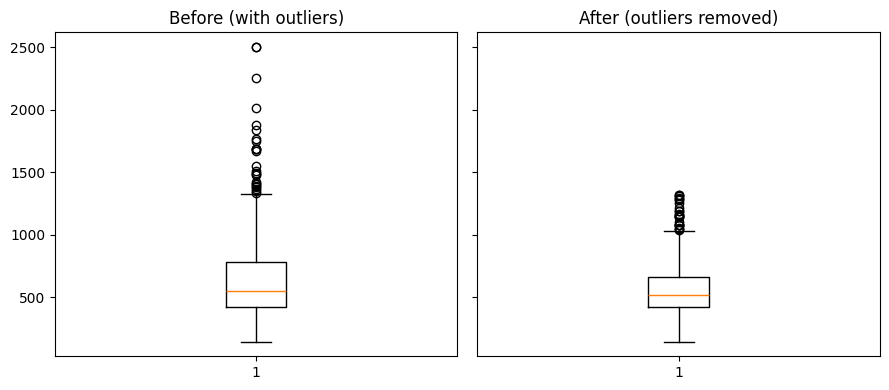

In [8]:
# ------------------------------------------------------------
# [목적] 박스플롯으로 '제거 전 vs 제거 후' 비교 (mean area 기준)
#   · 박스 밖 점 = 이상치 → 제거 후에는 그 점들이 사라진다
# ------------------------------------------------------------
import matplotlib.pyplot as plt                   # 그래프 그리기 (그림으로 보기)
%matplotlib inline

fig, ax = plt.subplots(1, 2, figsize=(9, 4), sharey=True)   # 그림 2칸 (같은 y축으로 비교)
ax[0].boxplot(X["mean area"])                     # 제거 전 (박스 위에 이상치 점이 보임)
ax[0].set_title("Before (with outliers)")         # 제목 (한글은 깨질 수 있어 영문)
ax[1].boxplot(df_clean["mean area"])              # 제거 후 (이상치가 빠져 점이 사라짐)
ax[1].set_title("After (outliers removed)")
plt.tight_layout()                                 # 간격 정리 (안 겹치게)
plt.show()                                         # 화면에 출력

In [9]:
# ============================================================
# [결과 해석]
#  · IQR(사분위수)는 '열 하나하나'를 따로 본다(단변량) — 어느 특성이 튀는지 콕 집혀 해석 쉬움
#  · out_count(이상치 특성 개수)로 '얼마나 유별난지' 순위를 매길 수 있음
#  · 스케일링·모델 불필요 / 한계: '조합만' 이상한 경우는 못 잡음(그건 IsolationForest)
#  · [정리] 한 값이 대놓고 튀면 -> IQR(박스플롯) / 조합이 이상하면 -> IsolationForest
# ============================================================

In [10]:
# ------------------------------------------------------------
# [실습] IQR로 이상치를 '제거하면' 이진분류가 더 잘될까? (정확도·ROC-AUC)
#   · 정답 target이 있어 이진분류로 검증 / 같은 시험셋으로 훈련셋만 바꿔 비교
# ------------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

y = df['target']                                  # 정답 (0=악성, 1=양성)
Xf = df[list(load_breast_cancer().feature_names)] # 원래 특성 30개만 (보조열 제외)
X_tr, X_te, y_tr, y_te = train_test_split(
    Xf, y, test_size=0.2, random_state=0, stratify=y)   # 8:2로 나누기 (비율 유지)

def score(A, b):                                  # 학습 후 '같은 시험셋'으로 정확도·AUC 반환
    m = LogisticRegression(max_iter=5000).fit(A, b)
    return accuracy_score(y_te, m.predict(X_te)), roc_auc_score(y_te, m.predict_proba(X_te)[:, 1])

acc0, auc0 = score(X_tr, y_tr)                     # (1) 원본 — 이상치 그대로 학습

Q1t, Q3t = X_tr.quantile(0.25), X_tr.quantile(0.75)   # 훈련셋 기준 IQR
IQRt = Q3t - Q1t
keep = (((X_tr < (Q1t - 1.5 * IQRt)) | (X_tr > (Q3t + 1.5 * IQRt))).sum(axis=1) == 0).values  # 안 튀는 행만
acc1, auc1 = score(X_tr[keep], y_tr[keep])         # (2) IQR 이상치 제거 후 학습

print(f'[원본]      정확도 {acc0:.3f} | ROC-AUC {auc0:.3f} | 훈련 {len(X_tr)}개')
print(f'[IQR 제거]  정확도 {acc1:.3f} | ROC-AUC {auc1:.3f} | 훈련 {int(keep.sum())}개')

[원본]      정확도 0.947 | ROC-AUC 0.992 | 훈련 455개
[IQR 제거]  정확도 0.956 | ROC-AUC 0.991 | 훈련 319개


In [11]:
# ============================================================
# [결과 해석] 많이 지운다고 좋아지는 게 아니다
#  · 정확도 0.947 -> 0.956 (소폭↑),  ROC-AUC 0.992 -> 0.991 (거의 그대로)
#  · IQR로 훈련 데이터를 455 -> 319개(약 30%)나 줄였는데 성능 이득은 미미
#  · 데이터를 너무 많이 버리면 오히려 손해일 수 있음
#  · 교훈: 이상치 제거는 '성능으로 검증'하고, 얼마나 지울지 신중히 결정!
# ============================================================